# In Silico `Toxicity` prediction for `Drugbank + Drugcentral` FDA approved drug Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

**Approved Drugs Data has been downloaded from Drugbank (https://go.drugbank.com/releases/latest#open-data). Now we are going to convert it to csv file to run DORAnet for all the possible substructures.**

In [2]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
resultsDir = os.path.join(dataDir, 'Toxicity/DrugBank/')
os.makedirs(resultsDir, exist_ok=True)

## Read `Drugbank` data

In [46]:
drugBankDrugDataDF_wSMILES = pd.read_csv(resultsDir + "drugBankDrugDataDF_wSMILES.csv", dtype=str)
print(f"Loaded {len(drugBankDrugDataDF_wSMILES)} molecules")
drugBankDrugDataDF_wSMILES

Loaded 14618 molecules


,DrugBank ID,Accession Numbers,Common name,CAS,UNII,Synonyms,Standard InChI Key,Canonical_SMILES
0,DB00006,BTD00076 | EXPT03302 | BIOD00076 | DB02351,Bivalirudin,128270-60-0,TN9BEX005G,Bivalirudin | Bivalirudina | Bivalirudinum,OIRCOABEOLEUMC-GEJPAHFPSA-N,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...
1,DB00014,BTD00113 | BIOD00113,Goserelin,65807-02-5,0F65R8P09N,Goserelin | Goserelina,BLCLNMBMMGCOAS-URPVMXJPSA-N,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
2,DB00027,BTD00036 | BIOD00036,Gramicidin D,1405-97-6,5IE62321P4,Bacillus brevis gramicidin D | Gramicidin | Gr...,NDAYQJDHGXTBJL-MWWSRJDJSA-N,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...
3,DB00035,BTD00112 | BTD00061 | BIOD00112 | BIOD00061,Desmopressin,16679-58-6,ENR1LLB0FP,1 deamino 8 D argininevasopressin | 1-(3-merca...,NFLWUMRGJYTJIN-PNIOQBSNSA-N,N=C(N)NCCC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]...
4,DB00050,BTD00115 | APRD00686 | BIOD00115,Cetrorelix,120287-85-6,OON1HFZ4BA,Cetrorelix | Cetrorelixum,SBNPWPIBESPSIF-MHWMIDJBSA-N,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
...,...,...,...,...,...,...,...,...
14613,DB30552,NaN,Dipalmitoyl hydroxyproline,41672-81-5,E6AHA53N1H,"Dipalmitoyl hydroxyproline | O,n-dipalmitoylhy...",QZLXCFQVOCEKSX-NOCHOARKSA-N,CCCCCCCCCCCCCCCC(=O)O[C@@H]1C[C@@H](C(=O)O)N(C...
14614,DB31698,NaN,R-(-)-Gossypol acetic acid,866541-93-7,U9GNI6VT5N,(-)-gossypol acetic acid | (r)-gossypol acetic...,NIOHNDKHQHVLKA-UHFFFAOYSA-N,CC(=O)O.Cc1cc2c(C(C)C)c(O)c(O)c(C=O)c2c(O)c1-c...
14615,DB31699,NaN,Gossypol acetic acid,5453-04-3,S7RL72610R,(+/-)-gossypol acetic acid | (±)-gossypol acet...,NIOHNDKHQHVLKA-UHFFFAOYSA-N,CC(=O)O.Cc1cc2c(C(C)C)c(O)c(O)c(C=O)c2c(O)c1-c...
14616,DB31734,NaN,FRAX597,1286739-19-2,NaN,NaN,DHUJCQOUWQMVCG-UHFFFAOYSA-N,CCn1c(=O)c(-c2ccc(-c3cncs3)cc2Cl)cc2cnc(Nc3ccc...


### Step 1 — Read predicted ADMET properties for all candidate SMILES

In [47]:
drugBankDrugDataDF_wSMILES_wToxicity = pd.read_csv(resultsDir + 'drugBankDrugDataDF_wSMILES_wToxicity.csv')
drugBankDrugDataDF_wSMILES_wToxicity

,Canonical_SMILES,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,tpsa,AMES,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,2180.317,-8.11643,29,28,1.0,0.014176,16,901.57,0.310810,...,1.046917,25.552540,59.053897,17.487398,16.130283,74.873982,20.666925,33.423808,48.623497,14.811943
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,1269.433,-3.10570,16,17,1.0,0.010267,9,495.89,0.576287,...,5.467235,42.303218,82.667701,1.706088,8.103916,40.558356,40.442032,50.368360,40.597131,5.622334
2,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,1811.253,4.86760,16,20,1.0,0.022619,13,519.89,0.278276,...,10.818147,67.235363,97.208220,97.983715,13.687476,94.416440,91.624661,93.563397,18.301667,53.431563
3,N=C(N)NCCC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]...,1069.238,-4.13203,15,14,1.0,0.027501,7,435.41,0.230986,...,0.969368,49.515316,70.104692,18.883288,23.109732,55.874370,23.419930,34.160527,38.309422,20.473052
4,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,1431.064,-0.50613,16,17,1.0,0.013447,10,495.67,0.276726,...,3.916247,29.158589,75.261729,31.717720,10.585498,74.369911,44.358278,54.905002,45.017449,38.309422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14123,CCCCCCCCCCCCCCCC(=O)O[C@@H]1C[C@@H](C(=O)O)N(C...,607.961,10.54630,4,1,2.0,0.064844,2,83.91,0.023694,...,18.611865,91.081815,96.200078,17.564948,89.220628,9.112059,85.498255,98.526561,2.442807,29.895308
14124,CC(=O)O.Cc1cc2c(C(C)C)c(O)c(O)c(C=O)c2c(O)c1-c...,578.614,6.47314,9,7,1.0,0.101848,0,192.82,0.100066,...,15.160915,6.165180,42.846064,95.851105,50.794882,61.535479,44.241954,83.210547,34.276851,58.045754
14125,CC(=O)O.Cc1cc2c(C(C)C)c(O)c(O)c(C=O)c2c(O)c1-c...,578.614,6.47314,9,7,1.0,0.101848,0,192.82,0.100066,...,15.160915,6.165180,42.846064,95.851105,50.794882,61.535479,44.241954,83.210547,34.276851,58.045754
14126,CCn1c(=O)c(-c2ccc(-c3cncs3)cc2Cl)cc2cnc(Nc3ccc...,558.111,5.75070,9,1,2.0,0.284585,0,79.18,0.280620,...,55.486623,30.632028,61.690578,90.732842,37.146181,49.554091,90.073672,92.943001,13.299729,92.051183


### Step 2 — retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [48]:
# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugDataDF_wSMILES_wToxicity.columns
]

drugBankDrugDataDF_wSMILES_wToxicity = drugBankDrugDataDF_wSMILES_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugDataDF_wSMILES_wToxicity.shape)
drugBankDrugDataDF_wSMILES_wToxicity.head()

Filtered dataframe shape: (14128, 33)


,AMES,hERG,DILI,ClinTox,Carcinogens_Lagunin,Skin_Reaction,LD50_Zhu,SR-ARE,SR-ATAD5,SR-HSE,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0.310810,0.203566,0.157990,0.117576,0.034491,0.183789,2.920528,0.097105,0.012814,0.006994,...,0.048505,0.257911,0.002577,0.022560,0.034454,0.003888,0.132853,0.180797,0.688971,0.086533
1,0.576287,0.761116,0.456281,0.369672,0.105431,0.098950,2.379779,0.064116,0.011034,0.008190,...,0.204220,0.378168,0.002031,0.054065,0.104391,0.054485,0.114031,0.145560,0.785328,0.423962
2,0.278276,0.818347,0.693615,0.084931,0.165993,0.073799,3.621140,0.335629,0.100212,0.068362,...,0.547499,0.439308,0.014953,0.290569,0.132428,0.223583,0.119283,0.031647,0.912250,0.933975
3,0.230986,0.228548,0.156015,0.054815,0.038481,0.154445,2.615314,0.106855,0.023336,0.012769,...,0.064727,0.227104,0.001188,0.014988,0.032820,0.002304,0.158653,0.082915,0.734302,0.149757
4,0.276726,0.769771,0.381344,0.164455,0.076909,0.082039,2.912322,0.103015,0.011854,0.012883,...,0.335595,0.400199,0.015246,0.185183,0.095395,0.076290,0.287348,0.330330,0.854831,0.771550


### Print range of all the endpoints

In [49]:
summaryStats = drugBankDrugDataDF_wSMILES_wToxicity[selectedCols].agg(
    ["min", "max", "mean", "std"]
).T

summaryStats.columns = ["Min", "Max", "Mean", "Std"]
summaryStats["Range"] = summaryStats["Max"] - summaryStats["Min"]
summaryStats = summaryStats[["Min", "Max", "Range", "Mean", "Std"]]

summaryStats.index.name = "Endpoint"

print("Summary statistics for all endpoints:")
print(summaryStats.to_string())

summaryStats.to_csv(resultsDir + 'drugBankDrugData_ADMET_summary.csv', index=True, encoding="utf-8")

Summary statistics for all endpoints:
                                         Min       Max     Range      Mean       Std
Endpoint                                                                            
AMES                            4.580234e-05  0.999994  0.999949  0.299619  0.249049
hERG                            5.135011e-05  0.997788  0.997737  0.434110  0.340795
DILI                            1.172916e-05  0.998585  0.998573  0.565484  0.337805
ClinTox                         6.131192e-09  0.955574  0.955574  0.217150  0.212429
Carcinogens_Lagunin             3.302558e-04  0.991252  0.990921  0.230227  0.199003
Skin_Reaction                   6.183962e-03  0.999993  0.993809  0.433260  0.253876
LD50_Zhu                       -4.707379e-02  6.023548  6.070622  2.546885  0.656044
SR-ARE                          2.767653e-05  0.999029  0.999002  0.272911  0.251478
SR-ATAD5                        3.475998e-13  0.986187  0.986187  0.058122  0.110646
SR-HSE                     

## Read the data of all the approved drugs from `Drugbank`

In [50]:
drugBankDrugDataDF_approved = pd.read_csv(resultsDir + 'drugbank_approved_structure_links.csv.zip')
drugBankDrugDataDF_approved.to_csv(resultsDir + 'drugbank_approved_structure_links.csv', index=False, encoding="utf-8")
drugBankDrugDataDF_approved

,DrugBank ID,Name,CAS Number,Drug Groups,InChIKey,InChI,SMILES,Formula,KEGG Compound ID,KEGG Drug ID,PubChem Compound ID,PubChem Substance ID,ChEBI ID,ChEMBL ID,HET ID,ChemSpider ID,BindingDB ID
0,DB00006,Bivalirudin,128270-60-0,approved; investigational,OIRCOABEOLEUMC-GEJPAHFPSA-N,InChI=1S/C98H138N24O33/c1-5-52(4)82(96(153)122...,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,C98H138N24O33,NaN,D03136,16129704.0,46507415.0,59173.0,CHEMBL2103749,NaN,10482069.0,50248103.0
1,DB00014,Goserelin,65807-02-5,approved; investigational,BLCLNMBMMGCOAS-URPVMXJPSA-N,InChI=1S/C59H84N18O14/c1-31(2)22-40(49(82)68-3...,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,C59H84N18O14,NaN,D00573,5311128.0,46507336.0,5523.0,CHEMBL1201247,NaN,4470656.0,50247974.0
2,DB00027,Gramicidin D,1405-97-6,approved; investigational,NDAYQJDHGXTBJL-MWWSRJDJSA-N,InChI=1S/C96H135N19O16/c1-50(2)36-71(105-79(11...,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,C96H135N19O16,NaN,D04369,45267103.0,46507412.0,NaN,CHEMBL557217,NaN,24623445.0,NaN
3,DB00035,Desmopressin,16679-58-6,approved; investigational,NFLWUMRGJYTJIN-PNIOQBSNSA-N,InChI=1S/C46H64N14O12S2/c47-35(62)15-14-29-40(...,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,C46H64N14O12S2,C06944,D00291,NaN,NaN,4450.0,CHEMBL1429,NaN,4470602.0,50247923.0
4,DB00050,Cetrorelix,120287-85-6,approved; investigational,SBNPWPIBESPSIF-MHWMIDJBSA-N,InChI=1S/C70H92ClN17O14/c1-39(2)31-52(61(94)82...,CC(C)C[C@H](NC(=O)[C@@H](CCCNC(N)=O)NC(=O)[C@H...,C70H92ClN17O14,NaN,D07665,25074887.0,46505494.0,59224.0,CHEMBL1200490,NaN,10482082.0,50369965.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,DB20138,Tribromsalan,87-10-5,approved; withdrawn,KVSKGMLNBAPGKH-UHFFFAOYSA-N,InChI=1S/C13H8Br3NO2/c14-7-1-3-9(4-2-7)17-13(1...,OC1=C(C=C(Br)C=C1Br)C(=O)NC1=CC=C(Br)C=C1,C13H8Br3NO2,NaN,NaN,NaN,NaN,127105.0,CHEMBL24944,NaN,NaN,234329.0
3016,DB20831,Iopydone,5579-93-1,approved; withdrawn,FRPFEVLOFNAKBS-UHFFFAOYSA-N,"InChI=1S/C5H3I2NO/c6-3-1-8-2-4(7)5(3)9/h1-2H,(...",IC1=CNC=C(I)C1=O,C5H3I2NO,NaN,NaN,NaN,NaN,NaN,CHEMBL2104367,NaN,NaN,NaN
3017,DB21667,Sevabertinib,2521285-05-0,approved; investigational,VYQVHWNNPKOJEA-AWEZNQCLSA-N,InChI=1S/C24H25ClN4O5/c1-31-23-16(25)3-2-4-18(...,COC1=C(NC2=C(NC3=C2C(=O)NCC3)C2=CC=NC=C2OC[C@@...,C24H25ClN4O5,NaN,NaN,NaN,NaN,NaN,CHEMBL6068074,NaN,NaN,NaN
3018,DB21811,Gozetotide,1366302-52-4,approved; investigational,QJUIUFGOTBRHKP-LQJZCPKCSA-N,InChI=1S/C44H62N6O17/c51-34-13-8-28(22-30(34)2...,OC(=O)CC[C@H](NC(=O)N[C@@H](CCCCNC(=O)CCCCCNC(...,C44H62N6O17,NaN,NaN,NaN,NaN,NaN,CHEMBL3578202,NaN,NaN,50089451.0


### Step 1 — Read predicted ADMET properties for all candidate SMILES

In [51]:
drugBankDrugDataDF_approved_wToxicity = pd.read_csv(resultsDir + 'drugbank_approved_structure_links_wToxicity.csv')
drugBankDrugDataDF_approved_wToxicity

,SMILES,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,tpsa,AMES,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,2180.317,-8.11643,29,28,1.0,0.014176,16,901.57,0.310810,...,1.046917,25.591314,59.053897,17.487398,16.169058,74.873982,20.666925,33.462582,48.623497,14.811943
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,1269.433,-3.10570,16,17,1.0,0.010267,9,495.89,0.576287,...,5.467235,42.303218,82.667701,1.706088,8.103916,40.558356,40.442032,50.368360,40.597131,5.622334
2,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...,1811.253,4.86760,16,20,1.0,0.022619,13,519.89,0.279331,...,10.856921,67.390461,97.246995,98.022489,13.842575,94.377666,91.973633,93.834820,18.069019,54.013183
3,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,1069.238,-4.13203,15,14,1.0,0.027501,7,435.41,0.246513,...,1.202016,51.221404,73.129120,18.069019,24.428073,59.015122,25.358666,36.952307,36.603335,22.217914
4,CC(C)C[C@H](NC(=O)[C@@H](CCCNC(N)=O)NC(=O)[C@H...,1431.064,-0.50613,16,17,1.0,0.013447,10,495.67,0.278756,...,3.916247,28.770841,74.718883,31.950368,10.507949,73.904614,43.660333,54.284606,45.405196,37.495153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2773,OC1=C(C=C(Br)C=C1Br)C(=O)NC1=CC=C(Br)C=C1,449.924,4.93200,2,2,4.0,0.682461,0,49.33,0.139711,...,55.796820,84.296239,71.074060,82.900349,48.545948,53.702986,94.920512,97.789841,7.444746,6.630477
2774,IC1=CNC=C(I)C1=O,346.893,1.58410,1,1,4.0,0.710881,0,32.86,0.091733,...,84.645211,57.115161,52.035673,79.139201,32.493214,46.994959,44.397053,39.511439,57.115161,96.161303
2775,COC1=C(NC2=C(NC3=C2C(=O)NCC3)C2=CC=NC=C2OC[C@@...,484.940,3.56240,7,3,4.0,0.470385,1,106.73,0.424901,...,31.678945,54.749903,65.451725,95.075611,20.279178,80.884064,81.155487,88.794106,11.593641,90.538969
2776,OC(=O)CC[C@H](NC(=O)N[C@@H](CCCCNC(=O)CCCCCNC(...,947.005,1.55450,13,12,1.0,0.043615,2,370.07,0.364973,...,4.071345,23.613804,59.790617,83.637069,18.456766,31.640171,16.130283,50.019387,78.402482,26.832105


### Step 2 — retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [52]:
# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugDataDF_approved_wToxicity.columns
]

drugBankDrugDataDF_approved_wToxicity = drugBankDrugDataDF_approved_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugDataDF_approved_wToxicity.shape)
drugBankDrugDataDF_approved_wToxicity.head()

Filtered dataframe shape: (2778, 33)


,AMES,hERG,DILI,ClinTox,Carcinogens_Lagunin,Skin_Reaction,LD50_Zhu,SR-ARE,SR-ATAD5,SR-HSE,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0.310810,0.203566,0.157990,0.117576,0.034491,0.183789,2.920528,0.097105,0.012814,0.006994,...,0.048505,0.257911,0.002577,0.022560,0.034454,0.003888,0.132853,0.180797,0.688971,0.086533
1,0.576287,0.761116,0.456281,0.369672,0.105431,0.098950,2.379779,0.064116,0.011034,0.008190,...,0.204220,0.378168,0.002031,0.054065,0.104391,0.054485,0.114031,0.145560,0.785328,0.423962
2,0.279331,0.820039,0.693912,0.084993,0.163415,0.074538,3.619984,0.340856,0.100954,0.069387,...,0.551455,0.436321,0.015546,0.298653,0.131439,0.232136,0.119051,0.033491,0.911799,0.936834
3,0.246513,0.253157,0.167744,0.058355,0.039024,0.149433,2.658192,0.133861,0.037735,0.017046,...,0.077015,0.216245,0.001653,0.021896,0.036195,0.003967,0.164736,0.095306,0.745049,0.218569
4,0.278756,0.763266,0.376340,0.169496,0.078289,0.081460,2.904686,0.099557,0.011483,0.012237,...,0.333679,0.404840,0.014637,0.170699,0.094969,0.068207,0.294748,0.321523,0.854312,0.765157


### Print range of all the endpoints

In [54]:
summaryStats = drugBankDrugDataDF_approved_wToxicity[selectedCols].agg(
    ["min", "max", "mean", "std"]
).T

summaryStats.columns = ["Min", "Max", "Mean", "Std"]
summaryStats["Range"] = summaryStats["Max"] - summaryStats["Min"]

summaryStats = summaryStats[["Min", "Max", "Range", "Mean", "Std"]]

print("Summary statistics for all endpoints:")
print(summaryStats.to_string())
summaryStats.to_csv(resultsDir + 'drugBankDrugData_approved_ADMET_summary.csv', index=True, index_label='Endpoint', encoding='utf-8')

Summary statistics for all endpoints:
                                         Min       Max     Range      Mean       Std
AMES                            5.837759e-05  0.999994  0.999936  0.267404  0.246170
hERG                            1.022494e-04  0.996943  0.996841  0.396913  0.346444
DILI                            1.754974e-05  0.997723  0.997706  0.486358  0.347489
ClinTox                         1.182336e-05  0.904089  0.904077  0.187615  0.206918
Carcinogens_Lagunin             3.267163e-04  0.989182  0.988855  0.226055  0.206324
Skin_Reaction                   1.151846e-02  0.998180  0.986662  0.463766  0.269045
LD50_Zhu                        2.533023e-01  5.018555  4.765253  2.527885  0.671969
SR-ARE                          8.631757e-05  0.994185  0.994098  0.232714  0.247490
SR-ATAD5                        7.235494e-08  0.934061  0.934061  0.043791  0.099153
SR-HSE                          5.968973e-07  0.959575  0.959575  0.062054  0.132050
SR-MMP                     

## Read `Drugbank` data (list of `withdrawn` drugs)

In [5]:
drugBankDrugWithdrawnDataDF_wSMILES = pd.read_csv(resultsDir + "DrugBank_withdrawn_drug_list.csv", dtype=str)
print(f"Loaded {len(drugBankDrugWithdrawnDataDF_wSMILES)} molecules")
drugBankDrugWithdrawnDataDF_wSMILES

Loaded 649 molecules


,DrugBank ID,Name,CAS Number,Drug Groups,InChIKey,InChI,SMILES,Formula,KEGG Compound ID,KEGG Drug ID,PubChem Compound ID,PubChem Substance ID,ChEBI ID,ChEMBL ID,HET ID,ChemSpider ID,BindingDB ID
0,DB00106,Abarelix,183552-38-7,approved; investigational; withdrawn,AIWRTTMUVOZGPW-HSPKUQOVSA-N,InChI=1S/C72H95ClN14O14/c1-41(2)32-54(64(93)80...,CC(C)C[C@H](NC(=O)[C@@H](CC(N)=O)NC(=O)[C@H](C...,C72H95ClN14O14,NaN,D02738,16131215,46508237,337298,CHEMBL1252,NaN,10482301,50102442
1,DB00131,Adenosine phosphate,61-19-8,approved; investigational; nutraceutical; with...,UDMBCSSLTHHNCD-KQYNXXCUSA-N,InChI=1S/C10H14N5O7P/c11-8-5-9(13-2-12-8)15(3-...,NC1=C2N=CN([C@@H]3O[C@H](COP(O)(O)=O)[C@@H](O)...,C10H14N5O7P,C00020,D02769,6083,46507628,16027,CHEMBL752,AMP,5858,18137
2,DB00132,alpha-Linolenic acid,463-40-1,approved; investigational; nutraceutical; with...,DTOSIQBPPRVQHS-PDBXOOCHSA-N,InChI=1S/C18H30O2/c1-2-3-4-5-6-7-8-9-10-11-12-...,CC\C=C/C\C=C/C\C=C/CCCCCCCC(O)=O,C18H30O2,C06427,NaN,5280934,46507620,27432,CHEMBL8739,LNL,4444437,51201294
3,DB00138,Cystine,56-89-3,approved; investigational; nutraceutical; with...,LEVWYRKDKASIDU-IMJSIDKUSA-N,InChI=1S/C6H12N2O4S2/c7-3(5(9)10)1-13-14-2-4(8...,N[C@@H](CSSC[C@H](N)C(O)=O)C(O)=O,C6H12N2O4S2,C00491,D03636,67678,46506670,16283,CHEMBL590540,IYY,60997,NaN
4,DB00150,Tryptophan,73-22-3,approved; investigational; nutraceutical; with...,QIVBCDIJIAJPQS-VIFPVBQESA-N,InChI=1S/C11H12N2O2/c12-9(11(14)15)5-7-6-13-10...,N[C@@H](CC1=CNC2=C1C=CC=C2)C(O)=O,C11H12N2O2,C00078,D00020,6305,46508329,16828,CHEMBL54976,TRP,6066,21974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,DB19382,Benzoylpas,13898-58-3,approved; withdrawn,GNZCRYWFWKFIDM-UHFFFAOYSA-N,InChI=1S/C14H11NO4/c16-12-8-10(6-7-11(12)14(18...,OC(=O)C1=CC=C(NC(=O)C2=CC=CC=C2)C=C1O,C14H11NO4,NaN,NaN,NaN,NaN,135059,CHEMBL1487804,NaN,NaN,50238677
645,DB19383,Pentapiperium,26372-86-1,approved; withdrawn,WSWDKMFWJOALEW-UHFFFAOYSA-N,InChI=1S/C19H30NO2/c1-5-15(2)18(16-9-7-6-8-10-...,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)C1=CC=CC=C1,C19H30NO2,NaN,NaN,NaN,NaN,134707,CHEMBL2111014,NaN,NaN,NaN
646,DB20118,Dichlorotetrafluoroethane,76-14-2,approved; withdrawn,DDMOUSALMHHKOS-UHFFFAOYSA-N,"InChI=1S/C2Cl2F4/c3-1(5,6)2(4,7)8",FC(F)(Cl)C(F)(F)Cl,C2Cl2F4,NaN,NaN,NaN,NaN,NaN,CHEMBL325436,NaN,NaN,NaN
647,DB20138,Tribromsalan,87-10-5,approved; withdrawn,KVSKGMLNBAPGKH-UHFFFAOYSA-N,InChI=1S/C13H8Br3NO2/c14-7-1-3-9(4-2-7)17-13(1...,OC1=C(C=C(Br)C=C1Br)C(=O)NC1=CC=C(Br)C=C1,C13H8Br3NO2,NaN,NaN,NaN,NaN,127105,CHEMBL24944,NaN,NaN,234329


In [8]:
# Keep only required columns
cols_to_keep = ['DrugBank ID', 'Drug Groups', 'Name', 'Formula', 'CAS Number', 'InChIKey', 'ChEMBL ID', 'SMILES']
drugBankDrugWithdrawnDataDF_wSMILES = drugBankDrugWithdrawnDataDF_wSMILES[cols_to_keep].copy()

# Canonicalize SMILES
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

drugBankDrugWithdrawnDataDF_wSMILES["SMILES"] = \
    drugBankDrugWithdrawnDataDF_wSMILES["SMILES"].apply(canonicalize)

# Drop rows where SMILES could not be canonicalized
invalid = drugBankDrugWithdrawnDataDF_wSMILES["SMILES"].isna().sum()
drugBankDrugWithdrawnDataDF_wSMILES = drugBankDrugWithdrawnDataDF_wSMILES.dropna(subset=["SMILES"]).reset_index(drop=True)

print(f"Valid compounds  : {len(drugBankDrugWithdrawnDataDF_wSMILES)}")
print(f"Invalid SMILES   : {invalid}")
drugBankDrugWithdrawnDataDF_wSMILES

Valid compounds  : 609
Invalid SMILES   : 40


,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES
0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...
2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O
3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O
4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O
...,...,...,...,...,...,...,...,...
604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1
605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1
606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl
607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O


### Predict ADMET properties for all `withdrawl` drugs from `DrugBank`

In [9]:
# Keep only rows with valid, non-empty SMILES
drugBankDrugWithdrawnDataDF_wSMILES_input = (
    drugBankDrugWithdrawnDataDF_wSMILES[
        drugBankDrugWithdrawnDataDF_wSMILES["SMILES"].notna() &
        (drugBankDrugWithdrawnDataDF_wSMILES["SMILES"].astype(str).str.strip() != "")
    ]
    .copy()
    .reset_index(drop=True)
)

# Predict ADMET properties
model = ADMETModel()
smilesList = drugBankDrugWithdrawnDataDF_wSMILES_input["SMILES"].tolist()

predictionsDF = model.predict(smiles=smilesList)
if not isinstance(predictionsDF, pd.DataFrame):
    predictionsDF = pd.DataFrame(predictionsDF)
predictionsDF = predictionsDF.reset_index()
if "index" in predictionsDF.columns and "SMILES" not in predictionsDF.columns:
    predictionsDF = predictionsDF.rename(columns={"index": "SMILES"})

# Merge ADMET predictions with original columns
drugBankDrugWithdrawnDataDF_wADMET = (
    drugBankDrugWithdrawnDataDF_wSMILES_input[['DrugBank ID', 'Drug Groups', 'Name', 'Formula', 'CAS Number', 'InChIKey', 'ChEMBL ID', 'SMILES']]
    .merge(predictionsDF, on="SMILES", how="left")
    .reset_index(drop=True)
)

print("Input shape     :", drugBankDrugWithdrawnDataDF_wSMILES_input.shape)
print("Predicted shape :", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,1416.089,1.1680,...,8.181466,17.487398,79.139201,56.882513,13.454827,64.172160,59.829391,74.757658,43.001163,37.456378
1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,347.224,-1.8630,...,9.305933,32.376890,30.205506,49.554091,2.442807,2.869329,28.576968,12.756883,82.822800,21.442420
2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,278.436,5.6605,...,42.923614,86.894145,52.578519,58.433501,92.012408,5.699884,77.704537,98.759209,15.548662,28.034122
3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,240.306,-0.8084,...,10.507949,63.435440,14.967041,21.636293,17.797596,8.607988,16.595580,31.911594,56.223342,63.784413
4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,204.229,1.1223,...,30.787127,11.360993,3.838697,30.787127,10.818147,39.084917,12.136487,51.454052,66.421093,43.233812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,257.245,2.3427,...,50.368360,62.466072,28.421869,13.609926,18.069019,9.112059,26.638232,64.598682,49.127569,61.108957
605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,304.454,3.5983,...,77.200465,86.234975,53.392788,19.697557,79.643273,74.796433,41.217526,14.307871,70.182241,25.552540
606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,170.920,2.6496,...,94.028693,36.797208,40.829779,68.165956,99.844901,0.271423,95.540907,73.090345,50.368360,89.841024
607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,449.924,4.9320,...,55.796820,84.296239,71.074060,82.900349,48.545948,53.702986,94.920512,97.789841,7.444746,6.630477


### Keep only relevant columns

In [11]:
# Potency-related columns
dataCols = [
    'DrugBank ID', 'Drug Groups', 'Name', 'Formula', 'CAS Number',
       'InChIKey', 'ChEMBL ID', 'SMILES'
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugWithdrawnDataDF_wADMET.columns
]

drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET.to_csv(resultsDir + 'drugBankDrugWithdrawnDataDF_wADMET.csv', encoding='utf-8')
drugBankDrugWithdrawnDataDF_wADMET

Filtered dataframe shape: (609, 41)


,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.244807,0.701052,...,0.463332,0.605704,0.017399,0.263449,0.207183,0.100211,0.232910,0.125635,0.925135,0.938593
1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,0.215953,0.123480,...,0.027663,0.470261,0.000746,0.008154,0.066037,0.003312,0.010593,0.036415,0.061753,0.000318
2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,0.494518,0.167146,...,0.737525,0.696307,0.166940,0.244747,0.189303,0.188501,0.161169,0.020346,0.343310,0.108636
3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,0.678855,0.033377,...,0.086299,0.860139,0.031484,0.182946,0.114121,0.124554,0.160284,0.026472,0.090174,0.046522
4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,0.227781,0.017756,...,0.227191,0.956495,0.102633,0.029928,0.428593,0.004736,0.231113,0.026281,0.171291,0.030738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,0.250689,0.040460,...,0.094615,0.934835,0.072102,0.036693,0.347887,0.206038,0.039468,0.026548,0.103570,0.006168
605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,0.010421,0.844745,...,0.845728,0.240165,0.000727,0.004731,0.050183,0.001061,0.538791,0.215035,0.560323,0.001474
606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,0.013408,0.420829,...,0.984755,0.942265,0.243439,0.567955,0.310735,0.045990,0.262644,0.001311,0.650809,0.001634
607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,0.139711,0.557277,...,0.753677,0.839571,0.949634,0.672943,0.431539,0.900576,0.232279,0.186494,0.658334,0.171204


# Read Drugbank approved data used in `ADMET-AI` article

source: https://zenodo.org/records/10372419

In [87]:
resultsDir

'/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Toxicity/DrugBank/'

In [55]:
drugBankDrug_FDAapproved = pd.read_csv(resultsDir + "drugbank_approved-admet_paper.csv", dtype=str)
print(f"Loaded {len(drugBankDrug_FDAapproved)} molecules")
drugBankDrug_FDAapproved

Loaded 2579 molecules


,name,id,smiles,atc,atc_name_1,atc_name_2,atc_name_3,atc_name_4,AMES,BBB_Martins,...,Solubility_AqSolDB,VDss_Lombardo,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,tpsa
0,"1,2-Benzodiazepine",DB12537,C1=Cc2ccccc2NN=C1,NaN,NaN,NaN,NaN,NaN,0.7549732685089111,0.9882773637771608,...,-2.5214576091560703,-5.783741598061894,144.17699999999996,2.1110999999999995,2,1,4.0,0.5921334832741901,0,24.39
1,"1,2-Distearoyllecithin",DB14099,CCCCCCCCCCCCCCCCCC(=O)OCC(COP(=O)([O-])OCC[N+]...,NaN,NaN,NaN,NaN,NaN,0.0157128114253282,0.4118771016597747,...,-4.864515912690619,7.828266300981383,790.1609999999991,12.172199999999988,8,0,2.0,0.0260053944034776,2,111.19
2,"1,2-icosapentoyl-sn-glycero-3-phosphoserine",DB14096,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCCC(=O)OC(COC...,NaN,NaN,NaN,NaN,NaN,0.5741199672222137,0.6174968600273132,...,-5.058148589198742,-2.5856110923079187,842.0640000000003,11.220399999999994,9,3,2.0,0.0235170830506975,3,171.68
3,1-Palmitoyl-2-oleoyl-sn-glycero-3-(phospho-rac...,DB11331;DB14095,CCCCCCCC/C=C\CCCCCCCC(=O)O[C@H](COC(=O)CCCCCCC...,NaN,NaN,NaN,NaN,NaN,0.0316610020585358,0.6007966339588166,...,-6.474748122427037,7.943757622635779,749.0200000000004,10.446999999999992,9,3,2.0,0.0239906879242251,3,148.82
4,"2,2'-Dibenzothiazyl disulfide",DB14201,c1ccc2sc(SSc3nc4ccccc4s3)nc2c1,NaN,NaN,NaN,NaN,NaN,0.4288192629814148,0.918051278591156,...,-5.487279800315363,-8.38811797756729,332.50000000000006,5.705400000000002,6,0,3.0,0.4490644198756372,0,25.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2574,alpha-Linolenic acid,DB00132,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,NaN,NaN,NaN,NaN,NaN,0.4945175528526306,0.8955767035484314,...,-4.899342053734773,-1.0614733346170795,278.4359999999999,5.660500000000005,1,1,3.0,0.3484104486085374,0,37.3
2575,alpha-Tocopherol succinate,DB14001;DBSALT001494,Cc1c(C)c2c(c(C)c1OC(=O)CCC(=O)O)CC[C@@](C)(CCC...,NaN,NaN,NaN,NaN,NaN,0.0220606921240687,0.6303920030593873,...,-6.910399541116336,-0.2804836338728716,530.7900000000005,8.904860000000003,4,1,2.0,0.1705634604813742,3,72.83000000000001
2576,gamma-Aminobutyric acid,DB02530;DB08850,NCCCC(=O)O,NaN,NaN,NaN,NaN,NaN,0.0784770206548273,0.78224858045578,...,0.8121850637061719,-3.520177999020634,103.12099999999998,-0.1900999999999997,2,2,4.0,0.5200092163601909,0,63.32000000000001
2577,gamma-Hydroxybutyric acid,DB01440,O=C(O)CCCO,NaN,NaN,NaN,NaN,NaN,0.0146741852164268,0.7724058628082275,...,1.0113147898182195,-1.384658175804803,104.105,-0.1565,2,2,4.0,0.5228516803190233,0,57.53


### Filter out Antivirals and Antibiotics

In [73]:
def hasAtcPrefix(atcValue, prefixes):
    if pd.isna(atcValue):
        return False

    tokens = [token.strip() for token in str(atcValue).split(";") if token.strip()]
    return any(any(token.startswith(prefix) for prefix in prefixes) for token in tokens)

def extractMatchingAtcCodes(atcValue, prefixes):
    if pd.isna(atcValue):
        return None

    tokens = [token.strip() for token in str(atcValue).split(";") if token.strip()]
    matchedTokens = [token for token in tokens if any(token.startswith(prefix) for prefix in prefixes)]

    if len(matchedTokens) == 0:
        return None

    return ";".join(matchedTokens)

def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

# Canonicalize smiles first
drugBankDrug_FDAapproved = drugBankDrug_FDAapproved.copy()
drugBankDrug_FDAapproved["smiles"] = drugBankDrug_FDAapproved["smiles"].apply(canonicalizeSmiles)

# Keep only rows with chemically valid canonical smiles
validSmilesMask = drugBankDrug_FDAapproved["smiles"].notna()

# Define code groups
antiinfectivePrefixes = ["J"]
antiviralPrefixes = ["J05"]
antibioticPrefixes = ["J01"]

# Build masks from ATC codes
antiinfectiveMask = drugBankDrug_FDAapproved["atc"].apply(
    lambda x: hasAtcPrefix(x, antiinfectivePrefixes)
)

antiviralMask = drugBankDrug_FDAapproved["atc"].apply(
    lambda x: hasAtcPrefix(x, antiviralPrefixes)
)

antibioticMask = drugBankDrug_FDAapproved["atc"].apply(
    lambda x: hasAtcPrefix(x, antibioticPrefixes)
)

otherAntiinfectiveMask = antiinfectiveMask & ~antiviralMask & ~antibioticMask

# Antiviral dataframe
drugBankDrug_FDAapproved_antiviral = (
    drugBankDrug_FDAapproved[antiviralMask & validSmilesMask]
    .copy()
    .reset_index(drop=True)
)
drugBankDrug_FDAapproved_antiviral["ATC_code"] = drugBankDrug_FDAapproved_antiviral["atc"].apply(
    lambda x: extractMatchingAtcCodes(x, antiviralPrefixes)
)
drugBankDrug_FDAapproved_antiviral["Drug_Type"] = "antiviral"

# Antibiotic dataframe
drugBankDrug_FDAapproved_antibiotic = (
    drugBankDrug_FDAapproved[antibioticMask & validSmilesMask]
    .copy()
    .reset_index(drop=True)
)
drugBankDrug_FDAapproved_antibiotic["ATC_code"] = drugBankDrug_FDAapproved_antibiotic["atc"].apply(
    lambda x: extractMatchingAtcCodes(x, antibioticPrefixes)
)
drugBankDrug_FDAapproved_antibiotic["Drug_Type"] = "antibiotic"

# Other antiinfective dataframe
drugBankDrug_FDAapproved_otherAntiinfective = (
    drugBankDrug_FDAapproved[otherAntiinfectiveMask & validSmilesMask]
    .copy()
    .reset_index(drop=True)
)
drugBankDrug_FDAapproved_otherAntiinfective["ATC_code"] = drugBankDrug_FDAapproved_otherAntiinfective["atc"].apply(
    lambda x: extractMatchingAtcCodes(x, antiinfectivePrefixes)
)
drugBankDrug_FDAapproved_otherAntiinfective["Drug_Type"] = "antiinfective"

print("Antiviral dataframe shape:", drugBankDrug_FDAapproved_antiviral.shape)
print("Antibiotic dataframe shape:", drugBankDrug_FDAapproved_antibiotic.shape)
print("Other antiinfective dataframe shape:", drugBankDrug_FDAapproved_otherAntiinfective.shape)

Antiviral dataframe shape: (77, 59)
Antibiotic dataframe shape: (154, 59)
Other antiinfective dataframe shape: (32, 59)


In [74]:
drugBankDrug_FDAapproved_antiviral.to_csv(resultsDir + 'drugBankDrug_FDAapproved_antiviral.csv', encoding='utf-8')
drugBankDrug_FDAapproved_antibiotic.to_csv(resultsDir + 'drugBankDrug_FDAapproved_antibiotic.csv', encoding='utf-8')
drugBankDrug_FDAapproved_otherAntiinfective.to_csv(resultsDir + 'drugBankDrug_FDAapproved_otherAntiinfective.csv', encoding='utf-8')

### Predict ADMET properties for all `FDA approved antiviral` from `DrugBank`

In [75]:
# Keep only rows with valid, non-empty SMILES
drugBankDrug_FDAapproved_antiviral_input = (
    drugBankDrug_FDAapproved_antiviral[
        drugBankDrug_FDAapproved_antiviral["smiles"].notna() &
        (drugBankDrug_FDAapproved_antiviral["smiles"].astype(str).str.strip() != "")
    ]
    .copy()
    .reset_index(drop=True)
)

# Initialize ADMET-AI model
model = ADMETModel()

# Get SMILES list
smilesList = drugBankDrug_FDAapproved_antiviral_input["smiles"].tolist()

# Predict ADMET properties
predictionsDF = model.predict(smiles=smilesList)

# Ensure predictions are a DataFrame and bring SMILES back as a column
if not isinstance(predictionsDF, pd.DataFrame):
    predictionsDF = pd.DataFrame(predictionsDF)

predictionsDF = predictionsDF.reset_index()

# Standardize the SMILES column name if needed
if "index" in predictionsDF.columns and "smiles" not in predictionsDF.columns:
    predictionsDF = predictionsDF.rename(columns={"index": "smiles"})

# Keep smiles + ATC_code + Drug_Type, then merge ADMET-AI predictions
drugBankDrug_FDAapproved_antiviral_wToxicity = (
    drugBankDrug_FDAapproved_antiviral_input[["smiles", "ATC_code", "Drug_Type"]]
    .merge(predictionsDF, on="smiles", how="left")
    .reset_index(drop=True)
)

print("Input antiviral dataframe shape:", drugBankDrug_FDAapproved_antiviral_input.shape)
print("Predicted antiviral ADMET dataframe shape:", drugBankDrug_FDAapproved_antiviral_wToxicity.shape)

drugBankDrug_FDAapproved_antiviral_wToxicity.to_csv(resultsDir + 'drugBankDrug_FDAapproved_antiviral_wToxicity.csv', encoding='utf-8')
drugBankDrug_FDAapproved_antiviral_wToxicity

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,286.339,1.09230,7,3,4.0,0.727230,2,...,21.713843,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,225.208,-1.33180,7,3,4.0,0.554386,0,...,12.252811,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,501.477,2.70250,13,1,2.0,0.207152,0,...,29.313687,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,505.637,2.40280,7,3,3.0,0.399740,3,...,26.211710,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,748.299,3.85380,10,3,3.0,0.285739,5,...,40.674680,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,267.245,-1.98000,9,4,4.0,0.490520,4,...,12.524234,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630
73,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,868.948,4.95650,11,3,2.0,0.303895,8,...,34.664599,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288
74,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,211.221,-0.50460,6,2,4.0,0.687546,2,...,37.999225,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497
75,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,332.313,-3.78550,7,7,3.0,0.188042,5,...,2.559131,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464


### Print ranges of all toxicity endpoints

In [78]:
summaryStats = drugBankDrug_FDAapproved_antiviral_wToxicity[selectedCols].agg(
    ["min", "max", "mean", "std"]
).T

summaryStats.columns = ["Min", "Max", "Mean", "Std"]
summaryStats["Range"] = summaryStats["Max"] - summaryStats["Min"]
summaryStats = summaryStats[["Min", "Max", "Range", "Mean", "Std"]]

summaryStats.index.name = "Endpoint"

print("Summary statistics for all endpoints:")
print(summaryStats.to_string())

Summary statistics for all endpoints:
                                     Min       Max     Range      Mean       Std
Endpoint                                                                        
AMES                            0.024560  0.986998  0.962438  0.411854  0.263844
hERG                            0.009766  0.969095  0.959329  0.503320  0.344423
DILI                            0.011779  0.984806  0.973027  0.775477  0.255180
ClinTox                         0.003851  0.738907  0.735055  0.292506  0.183371
Carcinogens_Lagunin             0.004122  0.593562  0.589440  0.177875  0.130717
Skin_Reaction                   0.048792  0.899098  0.850307  0.281144  0.202385
LD50_Zhu                        1.443178  4.646726  3.203548  2.892721  0.772347
SR-ARE                          0.006916  0.888055  0.881139  0.318180  0.280160
SR-ATAD5                        0.000148  0.613355  0.613207  0.066604  0.113564
SR-HSE                          0.000192  0.669190  0.668998  0.061034 

### Display 

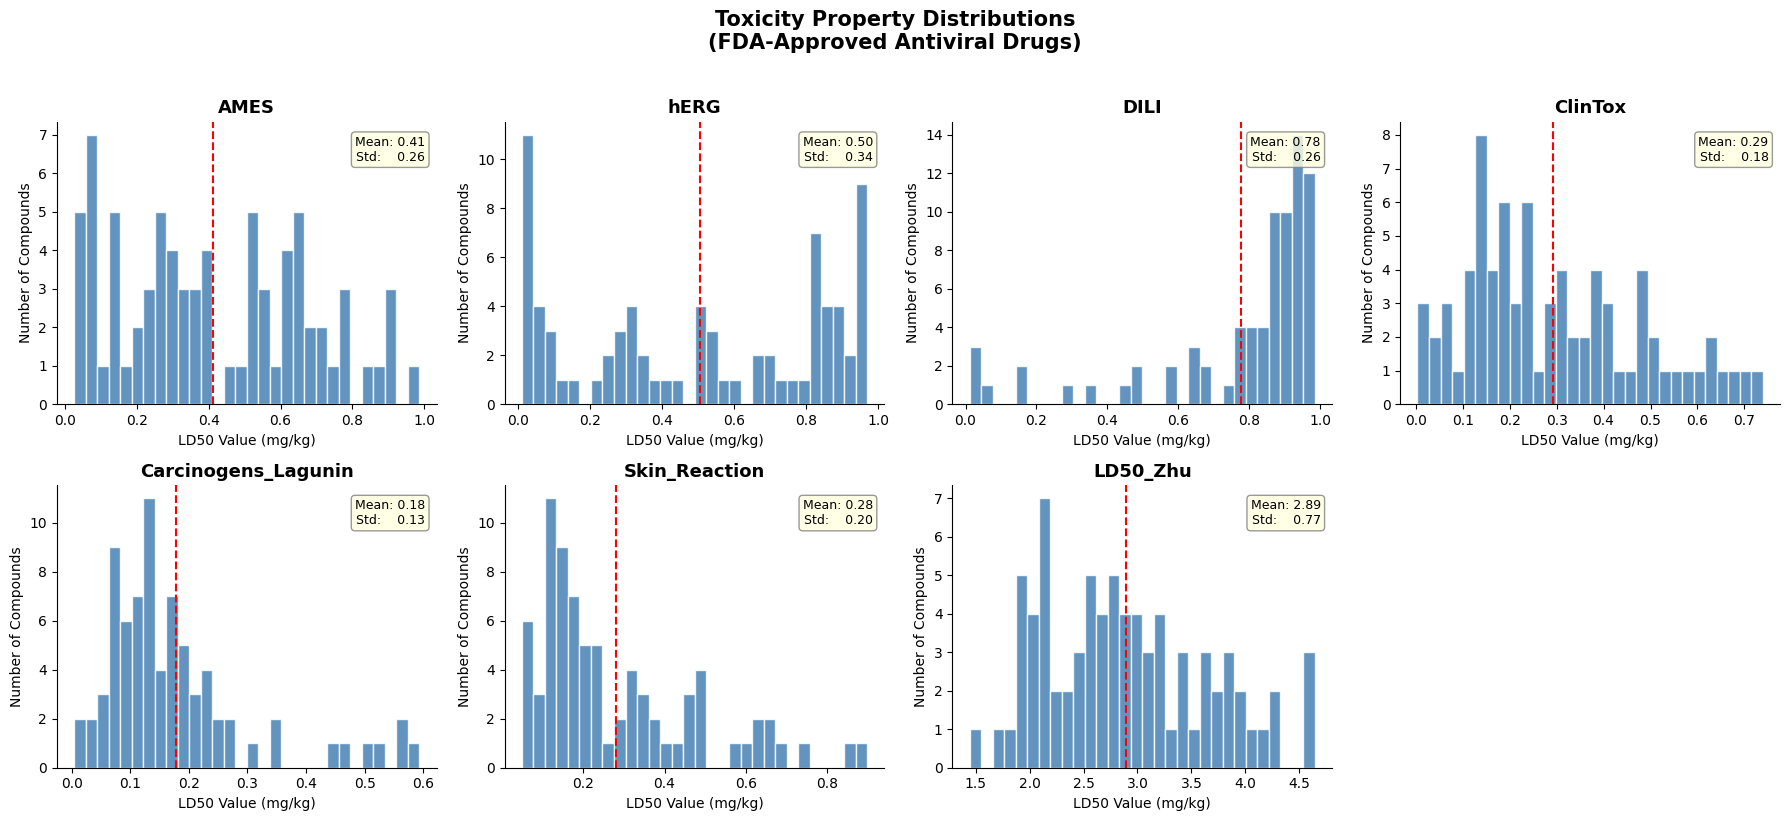

In [86]:
import matplotlib.pyplot as plt
import numpy as np

coreToxicityCols = ["AMES", "hERG", "DILI", "ClinTox", "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(coreToxicityCols):
    ax = axes[i]
    data = drugBankDrug_FDAapproved_antiviral_wToxicity[col].dropna()

    unique_vals = data.nunique()
    mean_val = data.mean()
    std_val = data.std()

    if unique_vals <= 5:
        counts = data.value_counts().sort_index()
        probs = counts / counts.sum()
        bars = ax.bar(counts.index.astype(str), probs.values, color=['steelblue', 'tomato', 'mediumseagreen', 'orange'][:len(counts)])
        ax.set_xlabel("Class")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1)
        for bar, prob in zip(bars, probs.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{prob:.2f}",
                    ha='center', va='bottom', fontsize=10)
    else:
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)  # removed density=True
        ax.set_xlabel("LD50 Value (mg/kg)")
        ax.set_ylabel("Number of Compounds")
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.text(0.97, 0.95, f"Mean: {mean_val:.2f}\nStd:    {std_val:.2f}",
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_visible(False)

plt.suptitle("Toxicity Property Distributions\n(FDA-Approved Antiviral Drugs)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Predict ADMET properties for all `FDA approved antibiotic` from `DrugBank`

In [76]:
# Keep only rows with valid, non-empty SMILES
drugBankDrug_FDAapproved_antibiotic_input = (
    drugBankDrug_FDAapproved_antibiotic[
        drugBankDrug_FDAapproved_antibiotic["smiles"].notna() &
        (drugBankDrug_FDAapproved_antibiotic["smiles"].astype(str).str.strip() != "")
    ]
    .copy()
    .reset_index(drop=True)
)

# Initialize ADMET-AI model
model = ADMETModel()

# Get SMILES list
smilesList = drugBankDrug_FDAapproved_antibiotic_input["smiles"].tolist()

# Predict ADMET properties
predictionsDF = model.predict(smiles=smilesList)

# Ensure predictions are a DataFrame and bring SMILES back as a column
if not isinstance(predictionsDF, pd.DataFrame):
    predictionsDF = pd.DataFrame(predictionsDF)

predictionsDF = predictionsDF.reset_index()

# Standardize the SMILES column name if needed
if "index" in predictionsDF.columns and "smiles" not in predictionsDF.columns:
    predictionsDF = predictionsDF.rename(columns={"index": "smiles"})

# Keep smiles + ATC_code + Drug_Type, then merge ADMET-AI predictions
drugBankDrug_FDAapproved_antibiotic_wToxicity = (
    drugBankDrug_FDAapproved_antibiotic_input[["smiles", "ATC_code", "Drug_Type"]]
    .merge(predictionsDF, on="smiles", how="left")
    .reset_index(drop=True)
)

print("Input antiviral dataframe shape:", drugBankDrug_FDAapproved_antibiotic_input.shape)
print("Predicted antiviral ADMET dataframe shape:", drugBankDrug_FDAapproved_antibiotic_wToxicity.shape)

drugBankDrug_FDAapproved_antibiotic_wToxicity.to_csv(resultsDir + 'drugBankDrug_FDAapproved_antibiotic_wToxicity.csv', encoding='utf-8')
drugBankDrug_FDAapproved_antibiotic_wToxicity

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,585.608,-8.4242,17,13,1.0,0.113064,16,...,0.620396,50.213261,31.136099,50.756107,2.132610,8.103916,6.397829,7.095774,91.779760,4.885615
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,365.411,0.0237,6,4,4.0,0.553032,4,...,5.777433,21.946491,39.278790,35.789066,14.618069,19.271035,13.609926,31.174874,70.104692,40.248158
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=...,J01CA;J01CR,antibiotic,349.412,0.3181,5,3,4.0,0.674878,4,...,10.663048,15.820085,45.676619,29.817759,15.122140,28.576968,10.585498,27.374952,68.631252,43.544009
3,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,J01FA;J01RA,antibiotic,748.996,1.9007,14,5,2.0,0.238475,18,...,14.075223,68.127181,57.735556,81.504459,28.654517,36.370686,31.950368,18.573090,66.033346,32.803412
4,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,461.500,0.0942,6,4,4.0,0.454446,4,...,7.599845,17.526173,74.059713,39.007367,18.960838,28.227995,14.385421,55.292749,51.337728,55.409073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,J01EA;J01EE,antibiotic,290.323,1.2576,7,2,4.0,0.853356,0,...,53.392788,55.486623,38.425746,12.989531,25.474990,44.668476,41.372625,34.548275,58.666150,13.881349
150,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,813.979,3.6209,16,0,2.0,0.186700,18,...,45.754168,92.400155,83.210547,74.408686,73.284219,76.424971,62.349748,49.864288,31.213649,88.677782
151,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,416.359,1.8945,6,2,4.0,0.676419,3,...,43.001163,22.024040,7.599845,48.933695,34.005428,65.451725,24.040326,30.942226,20.240403,20.744475
152,O=C(O)C[C@@H]1CC[C@H](NC(=O)Cc2cccs2)B(O)O1,J01DH,antibiotic,297.141,0.4488,5,3,4.0,0.685746,2,...,13.958899,25.474990,6.708026,29.391237,14.889492,54.556029,9.422257,37.417604,81.582009,22.217914


### Predict ADMET properties for all `FDA approved Antiinfective` from `DrugBank`

In [77]:
# Keep only rows with valid, non-empty SMILES
drugBankDrug_FDAapproved_otherAntiinfective_input = (
    drugBankDrug_FDAapproved_otherAntiinfective[
        drugBankDrug_FDAapproved_otherAntiinfective["smiles"].notna() &
        (drugBankDrug_FDAapproved_otherAntiinfective["smiles"].astype(str).str.strip() != "")
    ]
    .copy()
    .reset_index(drop=True)
)

# Initialize ADMET-AI model
model = ADMETModel()

# Get SMILES list
smilesList = drugBankDrug_FDAapproved_otherAntiinfective_input["smiles"].tolist()

# Predict ADMET properties
predictionsDF = model.predict(smiles=smilesList)

# Ensure predictions are a DataFrame and bring SMILES back as a column
if not isinstance(predictionsDF, pd.DataFrame):
    predictionsDF = pd.DataFrame(predictionsDF)

predictionsDF = predictionsDF.reset_index()

# Standardize the SMILES column name if needed
if "index" in predictionsDF.columns and "smiles" not in predictionsDF.columns:
    predictionsDF = predictionsDF.rename(columns={"index": "smiles"})

# Keep smiles + ATC_code + Drug_Type, then merge ADMET-AI predictions
drugBankDrug_FDAapproved_otherAntiinfective_wToxicity = (
    drugBankDrug_FDAapproved_otherAntiinfective_input[["smiles", "ATC_code", "Drug_Type"]]
    .merge(predictionsDF, on="smiles", how="left")
    .reset_index(drop=True)
)

print("Input antiviral dataframe shape:", drugBankDrug_FDAapproved_otherAntiinfective_input.shape)
print("Predicted antiviral ADMET dataframe shape:", drugBankDrug_FDAapproved_otherAntiinfective_wToxicity.shape)

drugBankDrug_FDAapproved_otherAntiinfective_wToxicity.to_csv(resultsDir + 'drugBankDrug_FDAapproved_otherAntiinfective_wToxicity.csv', encoding='utf-8')
drugBankDrug_FDAapproved_otherAntiinfective_wToxicity

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ccc(C(=O)O)c(O)c1,J04AA,antiinfective,153.137,0.67260,3,3,4.0,0.517606,0,...,25.358666,42.768515,16.518030,26.134161,22.915859,7.483521,16.052734,38.231873,69.445522,67.157813
1,C[C@@H]1[C@H](O)[C@@H](C)/C=C/C=C/C=C/C=C/C=C/...,J02AA,antiinfective,924.091,0.71170,17,12,1.0,0.173524,19,...,3.412175,30.476929,27.568825,58.123304,16.479256,72.741373,12.446685,39.123691,47.421481,8.142691
2,CCCCCOc1ccc(-c2ccc(-c3ccc(C(=O)N[C@H]4C[C@@H](...,J02AX,antiinfective,1140.254,-0.92710,17,14,1.0,0.067869,15,...,8.918185,38.735944,88.871656,86.894145,21.868941,89.724699,50.678558,89.181853,34.005428,23.381155
3,COc1nc2ccc(Br)cc2cc1[C@@H](c1ccccc1)[C@@](O)(C...,J04AK,antiinfective,555.516,7.13050,4,1,2.0,0.221355,2,...,52.229546,24.583172,74.602559,93.020551,52.849942,95.812330,93.602171,93.330748,5.738658,96.238852
4,C[C@@H]1NC(=O)[C@@H](N)CNC(=O)[C@H]([C@H]2CCN=...,J04AB,antiinfective,1321.435,-15.44200,27,27,1.0,0.053410,12,...,1.938736,3.450950,64.327259,90.228771,4.381543,92.051183,16.905777,12.407910,61.651803,74.098488
5,CC[C@H](C)C[C@H](C)CCCCCCCCC(=O)N[C@H]1C[C@@H]...,J02AX,antiinfective,1093.331,-3.31190,18,16,1.0,0.047716,16,...,4.497867,32.725863,89.375727,68.359829,25.552540,82.086080,39.782862,67.119038,30.244281,33.772780
6,CC(C)N=c1cc2n(-c3ccc(Cl)cc3)c3ccccc3nc-2cc1Nc1...,J04BA,antiinfective,473.407,7.48980,4,1,3.0,0.274930,0,...,69.057774,20.938348,39.550213,94.416440,74.292361,41.915471,87.708414,97.828616,3.838697,95.579682
7,N[C@@H]1CONC1=O,J04AB,antiinfective,102.093,-1.62490,3,2,4.0,0.385893,1,...,25.668864,10.663048,9.267158,59.906941,15.316014,34.664599,25.746413,10.624273,94.959287,56.494765
8,Nc1ccc(S(=O)(=O)c2ccc(N)cc2)cc1,J04BA,antiinfective,248.307,1.68380,4,2,4.0,0.791627,0,...,54.439705,52.539744,37.262505,79.875921,34.044203,24.079100,42.574641,42.729740,43.544009,28.693292
9,C[C@]1(COc2ccc(N3CCC(Oc4ccc(OC(F)(F)F)cc4)CC3)...,J04AK,antiinfective,534.491,4.96780,9,0,3.0,0.295120,1,...,58.937573,57.153936,75.649477,5.971307,86.234975,65.141528,97.440869,97.130671,6.785576,32.880962
